In [1]:
# ── Install (run once) ────────────────────────────────────────────────────────
# !pip install checkov pandas pyarrow datasets tqdm plotly kaleido --quiet

import os, json, subprocess, tempfile, textwrap, re
from pathlib import Path

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Column name constants (match parquet schema) ─────────────────────────────
_CODE_COL   = 'Reference output'
_PROMPT_COL = 'Prompt'
_DIFF_COL   = 'Difficulty'
_INTENT_COL = 'Intent'
_REGO_COL   = 'Rego intent'
_RES_COL    = 'Resource'

OUTPUT_DIR = Path('output/checkov_audit')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')


✅ Imports OK


In [35]:
# from datasets import load_dataset
# ds  = load_dataset("autoiac-project/iac-eval", split="test")
# df  = ds.to_pandas()

PARQUET_GLOB = './iac_benchmark/iac_eval_hf/data/train.parquet'           # ← adjust path if needed
df = pd.read_parquet(PARQUET_GLOB)

# Normalise difficulty to int if stored as string ("Level 1" → 1)
if df[_DIFF_COL].dtype == object:
    df[_DIFF_COL] = df[_DIFF_COL].str.extract(r'(\d)').astype(int)

# Drop rows with no reference code
df = df.dropna(subset=[_CODE_COL]).reset_index(drop=True)

print(f'Loaded {len(df):,} scenarios  |  columns: {list(df.columns)}')
df.head(2)

Loaded 458 scenarios  |  columns: ['Resource', 'Prompt', 'Rego intent', 'Difficulty', 'Reference output', 'Intent']


,Resource,Prompt,Rego intent,Difficulty,Reference output,Intent
0,"aws_cloudwatch_log_group, aws_cloudwatch_log_r...",Configure a query log that can create a log st...,package terraform.validation\n\ndefault is_con...,5,terraform {\n required_providers {\n aws =...,"Has one ""aws_route53_zone"" resource\n with ..."
1,"aws_route53_vpc_association_authorization, aws...",Configure a valid Route 53 zone association re...,package terraform.validation\n\ndefault is_con...,3,"provider ""aws"" {\n region = ""us-east-1""\n}\...","Has multiple ""aws_vpc"" resource\n with a sp..."


In [37]:
# import subprocess, sys

# # Uninstall current broken install
# subprocess.run([sys.executable, '-m', 'pip', 'uninstall', 'checkov', '-y'], check=False)

# # Reinstall pinned to a known-good version for Python 3.12
# subprocess.run([
#     sys.executable, '-m', 'pip', 'install',
#     'checkov==3.2.350',          # last stable release before yaml-loader refactor
#     'pyyaml>=6.0.1',
#     'bc-python-hcl2>=0.3.51',
#     '--force-reinstall',
#     '--quiet',
# ], check=True)

# # Verify
# result = subprocess.run(['checkov', '--version'], capture_output=True, text=True)
# print('Checkov version:', result.stdout.strip())
# print('stderr:', result.stderr.strip())


In [39]:
# ── Diagnostic: inspect raw Checkov output for one template ──────────────────
sample_code = df[_CODE_COL].iloc[0]

with tempfile.TemporaryDirectory() as tmpdir:
    tf_path = Path(tmpdir) / 'main.tf'
    tf_path.write_text(str(sample_code), encoding='utf-8')

    proc = subprocess.run(
        ['checkov', '-f', str(tf_path), '--framework', 'terraform', '-o', 'json', '--quiet', '--compact'],
        capture_output=True, text=True, timeout=60
    )
    print('=== RETURN CODE ===')
    print(proc.returncode)
    print('=== STDOUT (first 3000 chars) ===')
    print(proc.stdout[:3000])
    print('=== STDERR (first 1000 chars) ===')
    print(proc.stderr[:1000])

=== RETURN CODE ===
1
=== STDOUT (first 3000 chars) ===
{
    "check_type": "terraform",
    "results": {
        "failed_checks": [
            {
                "check_id": "CKV_AWS_338",
                "bc_check_id": "BC_AWS_LOGGING_46",
                "check_name": "Ensure CloudWatch log groups retains logs for at least 1 year",
                "check_result": {
                    "result": "FAILED",
                    "evaluated_keys": []
                },
                "code_block": null,
                "file_path": "/main.tf",
                "file_abs_path": "/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/tmpcpmihme2/main.tf",
                "repo_file_path": "/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/tmpcpmihme2/main.tf",
                "file_line_range": [
                    26,
                    29
                ],
                "resource": "aws_cloudwatch_log_group.aws_route53_example_com",
                "evaluations": null,
                "chec

In [79]:
def run_checkov(tf_code: str, timeout: int = 60) -> dict:
    result = {
        'checkov_passed':      False,
        'checkov_error':       None,
        'total_checks':        0,
        'passed_checks':       0,
        'failed_checks':       0,
        'policy_pass_rate':    None,
        'filtered_compliance': False,
        'severity_high':       0,
        'severity_medium':     0,
        'severity_low':        0,
        'severity_info':       0,
        'violations':          [],
        'cis_violations':      [],
        'violation_ids':       [],
        'violation_names':     [],
        'checkov_log':         '',
    }

    with tempfile.TemporaryDirectory() as tmpdir:
        tf_path = Path(tmpdir) / 'main.tf'
        tf_path.write_text(str(tf_code), encoding='utf-8')

        cmd = [
            'checkov',
            '-f', str(tf_path),
            '--framework', 'terraform',
            '-o', 'json',
            '--quiet',
            '--compact',
            '--skip-download',        # avoids registry fetch that can emit extra text
        ]

        try:
            proc = subprocess.run(
                cmd, capture_output=True, text=True, timeout=timeout
            )
        except subprocess.TimeoutExpired:
            result['checkov_error'] = 'TimeoutExpired'
            return result
        except FileNotFoundError:
            result['checkov_error'] = 'checkov_not_found'
            return result
        except Exception as e:
            result['checkov_error'] = str(e)
            return result

        raw_stdout = proc.stdout
        raw_stderr = proc.stderr
        result['checkov_log'] = raw_stdout[:4000] + raw_stderr[:500]

        # ── Robust JSON extraction ────────────────────────────────────────
        # Checkov sometimes emits log lines / ANSI codes before the JSON blob.
        # Strategy: find the first '[' or '{' that starts a valid JSON structure.
        raw = None

        # Try 1: direct parse (clean output)
        try:
            raw = json.loads(raw_stdout)
        except json.JSONDecodeError:
            pass

        # Try 2: strip ANSI escape codes then parse
        if raw is None:
            clean = re.sub(r'\x1b\[[0-9;]*m', '', raw_stdout)
            try:
                raw = json.loads(clean)
            except json.JSONDecodeError:
                pass

        # Try 3: find first JSON array or object in the output (skip leading log lines)
        if raw is None:
            for start_char, end_char in [('[', ']'), ('{', '}')]:
                idx = raw_stdout.find(start_char)
                if idx != -1:
                    candidate = raw_stdout[idx:]
                    # trim to balanced close
                    depth, end_idx = 0, -1
                    for i, ch in enumerate(candidate):
                        if ch == start_char: depth += 1
                        elif ch == end_char:
                            depth -= 1
                            if depth == 0:
                                end_idx = i + 1
                                break
                    if end_idx != -1:
                        try:
                            raw = json.loads(candidate[:end_idx])
                            break
                        except json.JSONDecodeError:
                            pass

        if raw is None:
            result['checkov_error'] = 'json_parse_failed'
            result['checkov_log']   = raw_stdout[:2000] + '\nSTDERR: ' + raw_stderr[:500]
            return result

        # ── Normalise: Checkov v2 wraps in list, v3 may return dict directly ─
        if isinstance(raw, list):
            # filter to terraform results only
            tf_results = [r for r in raw if r.get('check_type') == 'terraform']
            raw = tf_results[0] if tf_results else (raw[0] if raw else {})

        # ── Summary counts ─────────────────────────────────────────────────
        summary = raw.get('summary', {})
        result['passed_checks'] = int(summary.get('passed',  0))
        result['failed_checks'] = int(summary.get('failed',  0))
        result['total_checks']  = result['passed_checks'] + result['failed_checks']

        if result['total_checks'] > 0:
            result['policy_pass_rate'] = round(
                result['passed_checks'] / result['total_checks'], 4
            )
        result['filtered_compliance'] = (result['total_checks'] > 0
                                         and result['failed_checks'] == 0)

        # ── Map failed checks ──────────────────────────────────────────────
        _SEV_MAP = {
            'HIGH': 'severity_high', 'MEDIUM': 'severity_medium',
            'LOW': 'severity_low',   'INFO': 'severity_info',
            'INFORMATIONAL': 'severity_info',
        }

        for chk in raw.get('results', {}).get('failed_checks', []):
            sev = (chk.get('severity') or 'LOW').upper()
            check_id   = chk.get('check_id',   '')
            check_name = chk.get('check_name', check_id)

            item = {
                'check_id':      check_id,
                'check_name':    check_name,
                'resource':      chk.get('resource', ''),
                'resource_type': chk.get('resource', '').split('.')[0],
                'severity':      sev,
                'guideline':     chk.get('guideline', ''),
                'file_line':     chk.get('file_line_range', []),
            }
            result['violations'].append(item)
            result['violation_ids'].append(check_id)
            result['violation_names'].append(check_name)
            result[_SEV_MAP.get(sev, 'severity_low')] += 1

            if re.match(r'CKV_AWS_', check_id):
                result['cis_violations'].append(check_id)

        result['checkov_passed'] = result['filtered_compliance']
        return result


In [81]:
# ── Batch scan ────────────────────────────────────────────────────────────────
checkov_results = []

for code in tqdm(df[_CODE_COL], desc='Checkov scan', unit='template'):
    checkov_results.append(run_checkov(str(code)))

# ── Expand flat scalar columns into the main dataframe ───────────────────────
SCALAR_COLS = [
    'checkov_passed', 'checkov_error',
    'total_checks', 'passed_checks', 'failed_checks',
    'policy_pass_rate', 'filtered_compliance',
    'severity_high', 'severity_medium', 'severity_low', 'severity_info',
    'checkov_log',
]

df_chk = pd.DataFrame(checkov_results)
for col in SCALAR_COLS:
    df[col] = df_chk[col]

# Keep list columns separate (not great in a flat DataFrame)
df['violation_ids']   = df_chk['violation_ids']
df['violation_names'] = df_chk['violation_names']
df['violations_json'] = df_chk['violations'].apply(json.dumps)  # serialisable
df['cis_violations']  = df_chk['cis_violations']

# ── Severity-weighted violation score (HIGH=3, MED=2, LOW=1, INFO=0.5) ────────
df['swvs'] = (
    df['severity_high']   * 3 +
    df['severity_medium'] * 2 +
    df['severity_low']    * 1 +
    df['severity_info']   * 0.5
)

print(f"\nCheckov scan complete")
print(f"  Templates scanned          : {len(df):,}")
print(f"  Fully compliant (FCR)      : {df['filtered_compliance'].sum():,}  "
      f"({df['filtered_compliance'].mean()*100:.1f}%)")
print(f"  Mean policy pass rate (PPR): {df['policy_pass_rate'].mean()*100:.1f}%")
print(f"  Total violations found     : {df['failed_checks'].sum():,}")


Checkov scan:   0%|          | 0/458 [00:00<?, ?template/s]


Checkov scan complete
  Templates scanned          : 458
  Fully compliant (FCR)      : 59  (12.9%)
  Mean policy pass rate (PPR): 57.6%
  Total violations found     : 3,316


In [83]:
# Save full results (list columns serialised as JSON strings)
SAVE_COLS = list(df.columns)
save_df = df.copy()
# list-type cols → JSON string for CSV compatibility
for lc in ['violation_ids', 'violation_names', 'cis_violations']:
    save_df[lc] = save_df[lc].apply(json.dumps)

save_df[SAVE_COLS].to_csv(OUTPUT_DIR / 'iac_eval_checkov_results.csv', index=False)
save_df[SAVE_COLS].to_parquet(OUTPUT_DIR / 'iac_eval_checkov_results.parquet', index=False)
print(f'Saved enriched dataset → {OUTPUT_DIR}')
print(save_df.columns)
save_df[['Prompt','Reference output','checkov_passed', 'checkov_error', 'total_checks',
       'passed_checks', 'failed_checks', 'policy_pass_rate',
       'filtered_compliance', 'severity_high', 'severity_medium',
       'severity_low', 'severity_info', 'checkov_log', 'violation_ids',
       'violation_names', 'violations_json', 'cis_violations', 'swvs']].head()

Saved enriched dataset → output/checkov_audit
Index(['Resource', 'Prompt', 'Rego intent', 'Difficulty', 'Reference output',
       'Intent', 'checkov_passed', 'checkov_error', 'total_checks',
       'passed_checks', 'failed_checks', 'policy_pass_rate',
       'filtered_compliance', 'severity_high', 'severity_medium',
       'severity_low', 'severity_info', 'checkov_log', 'violation_ids',
       'violation_names', 'violations_json', 'cis_violations', 'swvs'],
      dtype='object')


,Prompt,Reference output,checkov_passed,checkov_error,total_checks,passed_checks,failed_checks,policy_pass_rate,filtered_compliance,severity_high,severity_medium,severity_low,severity_info,checkov_log,violation_ids,violation_names,violations_json,cis_violations,swvs
0,Configure a query log that can create a log st...,terraform {\n required_providers {\n aws =...,False,None,17,14,3,0.8235,False,0,0,3,0,"{\n ""check_type"": ""terraform"",\n ""result...","[""CKV_AWS_338"", ""CKV_AWS_158"", ""CKV2_AWS_38""]","[""Ensure CloudWatch log groups retains logs fo...","[{""check_id"": ""CKV_AWS_338"", ""check_name"": ""En...","[""CKV_AWS_338"", ""CKV_AWS_158""]",3.0
1,Configure a valid Route 53 zone association re...,"provider ""aws"" {\n region = ""us-east-1""\n}\...",False,None,7,1,6,0.1429,False,0,0,6,0,"{\n ""check_type"": ""terraform"",\n ""result...","[""CKV2_AWS_12"", ""CKV2_AWS_12"", ""CKV2_AWS_39"", ...","[""Ensure the default security group of every V...","[{""check_id"": ""CKV2_AWS_12"", ""check_name"": ""En...",[],6.0
2,Configure a Route 53 record with an Elastic Lo...,"provider ""aws"" {\n region = ""us-east-1""\n}\n\...",False,None,9,4,5,0.4444,False,0,0,5,0,"{\n ""check_type"": ""terraform"",\n ""result...","[""CKV_AWS_127"", ""CKV_AWS_92"", ""CKV_AWS_376"", ""...","[""Ensure that Elastic Load Balancer(s) uses SS...","[{""check_id"": ""CKV_AWS_127"", ""check_name"": ""En...","[""CKV_AWS_127"", ""CKV_AWS_92"", ""CKV_AWS_376""]",5.0
3,"Using route 53 resources, configure a weighted...",terraform {\n required_providers {\n aws =...,False,None,60,20,40,0.3333,False,0,0,40,0,"{\n ""check_type"": ""terraform"",\n ""result...","[""CKV_AWS_161"", ""CKV_AWS_354"", ""CKV_AWS_293"", ...","[""Ensure RDS database has IAM authentication e...","[{""check_id"": ""CKV_AWS_161"", ""check_name"": ""En...","[""CKV_AWS_161"", ""CKV_AWS_354"", ""CKV_AWS_293"", ...",40.0
4,Configure Route 53 to return different databas...,terraform {\n required_providers {\n aws =...,False,None,35,10,25,0.2857,False,0,0,25,0,"{\n ""check_type"": ""terraform"",\n ""result...","[""CKV_AWS_161"", ""CKV_AWS_354"", ""CKV_AWS_293"", ...","[""Ensure RDS database has IAM authentication e...","[{""check_id"": ""CKV_AWS_161"", ""check_name"": ""En...","[""CKV_AWS_161"", ""CKV_AWS_354"", ""CKV_AWS_293"", ...",25.0


In [85]:
# ── Explode violation_ids to get per-check counts ─────────────────────────────
all_violations = (
    df[['violation_ids', 'violation_names', _DIFF_COL, _RES_COL]]
    .explode('violation_ids')
    .rename(columns={'violation_ids': 'check_id'})
    .dropna(subset=['check_id'])
    .query("check_id != ''")
)

# Attach human-readable names
name_map = (
    df.explode('violation_ids')
      .assign(check_id=lambda x: x['violation_ids'])
      .explode('violation_names')
      .assign(check_name=lambda x: x['violation_names'])
      [['check_id', 'check_name']]
      .dropna()
      .drop_duplicates('check_id')
      .set_index('check_id')['check_name']
      .to_dict()
)
all_violations['check_name'] = all_violations['check_id'].map(name_map)

# ── Top violations overall ────────────────────────────────────────────────────
top_violations = (
    all_violations.groupby(['check_id', 'check_name'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(20)
)

# ── Violations by difficulty ───────────────────────────────────────────────────
vuln_by_diff = (
    all_violations.groupby([_DIFF_COL, 'check_id'])
    .size()
    .reset_index(name='count')
)

# ── Summary table by difficulty ────────────────────────────────────────────────
# policy_pass_rate is None for templates with 0 applicable checks → cast to float first
df['policy_pass_rate'] = pd.to_numeric(df['policy_pass_rate'], errors='coerce')

summary_table = (
    df.groupby(_DIFF_COL)
    .agg(
        scenarios          = (_CODE_COL,            'count'),
        pct_compliant      = ('filtered_compliance', 'mean'),
        mean_ppr           = ('policy_pass_rate',    'mean'),   # NaN-safe mean
        mean_violations    = ('failed_checks',       'mean'),
        mean_swvs          = ('swvs',                'mean'),
        total_high         = ('severity_high',       'sum'),
        total_medium       = ('severity_medium',     'sum'),
        total_low          = ('severity_low',        'sum'),
    )
    .reset_index()
)

# Safe percentage conversion – fillna(0) handles groups with no applicable checks
summary_table['pct_compliant'] = (summary_table['pct_compliant'].fillna(0) * 100).round(1)
summary_table['mean_ppr']      = (summary_table['mean_ppr'].fillna(0)      * 100).round(1)
summary_table['mean_violations']= summary_table['mean_violations'].round(1)
summary_table['mean_swvs']      = summary_table['mean_swvs'].round(2)

print(summary_table.to_string(index=False))



 Difficulty  scenarios  pct_compliant  mean_ppr  mean_violations  mean_swvs  total_high  total_medium  total_low
          1         45           15.6      45.4              2.7       2.69           0             0        121
          2         95           14.7      48.1              4.2       4.18           0             0        397
          3        113           23.0      60.9              3.3       3.32           0             0        375
          4         58           12.1      64.2              7.0       7.02           0             0        407
          5         72            1.4      62.6             11.4      11.40           0             0        821
          6         75            5.3      58.0             15.9      15.93           0             0       1195


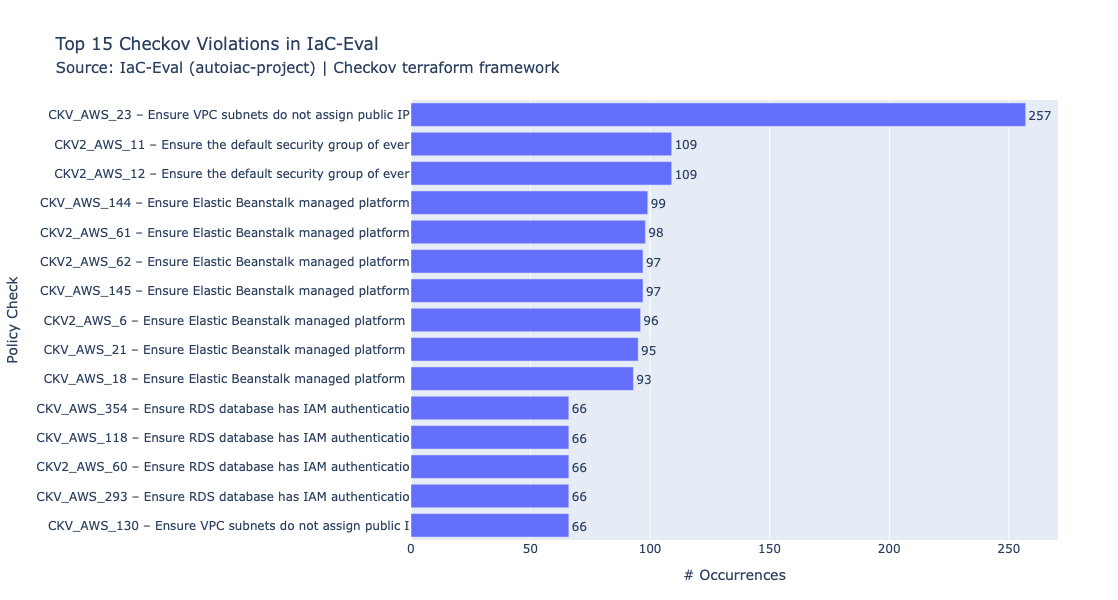

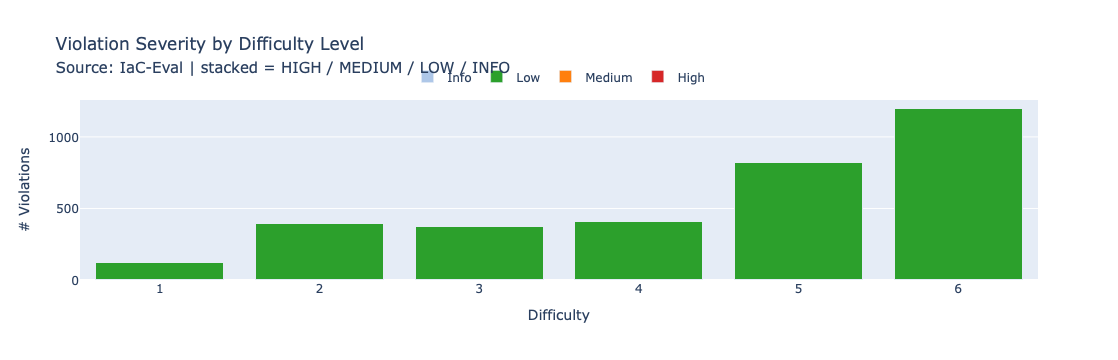

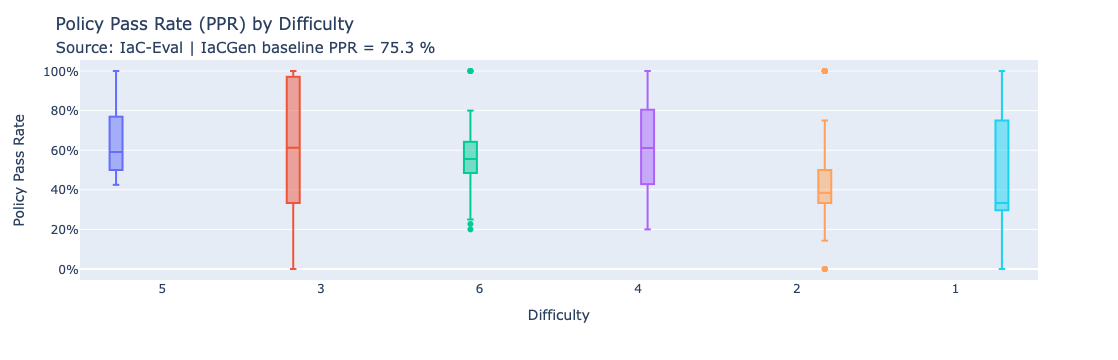

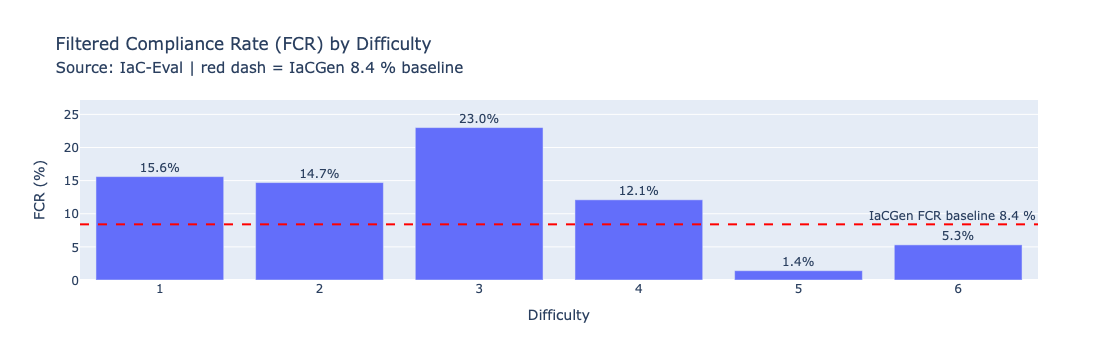

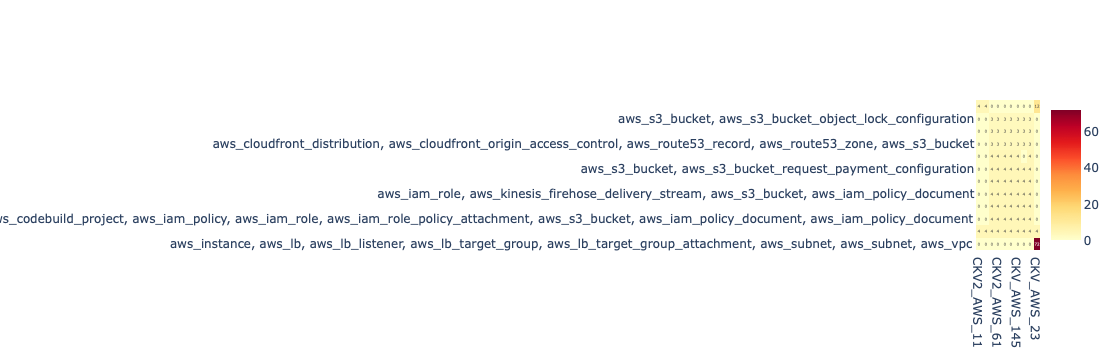

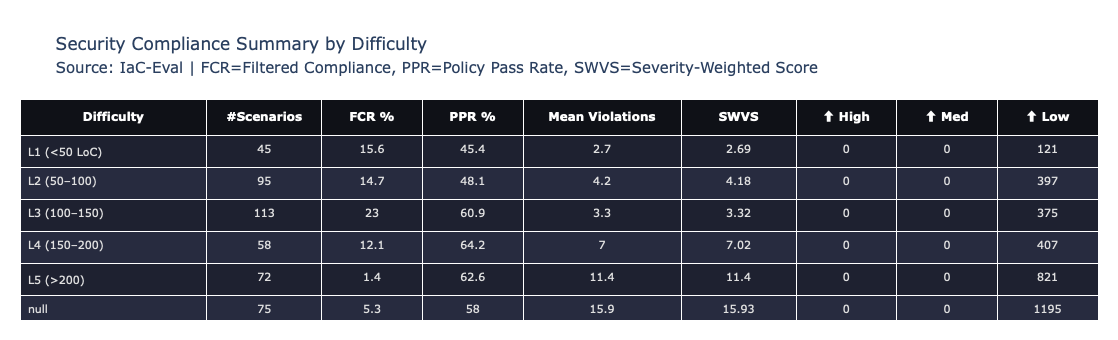

All 6 figures saved → output/checkov_audit


In [87]:
import json as _json

# ── 1. Top 15 Vulnerabilities (horizontal bar) ────────────────────────────────
top15 = top_violations.head(15).sort_values('count')
label = top15['check_id'] + ' – ' + top15['check_name'].fillna('')
label = label.str[:55]   # truncate long names

fig1 = go.Figure(go.Bar(
    x=top15['count'], y=label, orientation='h',
    text=top15['count'], textposition='outside',
))
fig1.update_layout(
    title=dict(text=(
        'Top 15 Checkov Violations in IaC-Eval<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval (autoiac-project) | Checkov terraform framework"
        "</span>"
    )),
    xaxis_title='# Occurrences',
    yaxis_title='Policy Check',
    margin=dict(l=380, r=60, t=100, b=60),
    height=600,
)
fig1.update_traces(cliponaxis=False)
fig1.show()
fig1.write_image(str(OUTPUT_DIR / 'top15_violations.png'))
with open(str(OUTPUT_DIR / 'top15_violations.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Top 15 Checkov policy violations across IaC-Eval templates',
                'description': 'Horizontal bar chart counting each failed Checkov check'}, f)

# ── 2. Severity breakdown (stacked bar by difficulty) ─────────────────────────
sev_cols   = ['severity_high', 'severity_medium', 'severity_low', 'severity_info']
sev_labels = ['High', 'Medium', 'Low', 'Info']
sev_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#aec7e8']

sev_by_diff = df.groupby(_DIFF_COL)[sev_cols].sum().reset_index()

fig2 = go.Figure()
for col, label2, color in zip(sev_cols, sev_labels, sev_colors):
    fig2.add_bar(
        x=sev_by_diff[_DIFF_COL].astype(str),
        y=sev_by_diff[col],
        name=label2,
        marker_color=color,
    )
fig2.update_layout(
    barmode='stack',
    title=dict(text=(
        'Violation Severity by Difficulty Level<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | stacked = HIGH / MEDIUM / LOW / INFO"
        "</span>"
    )),
    xaxis_title='Difficulty',
    yaxis_title='# Violations',
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
)
fig2.show()
fig2.write_image(str(OUTPUT_DIR / 'severity_by_difficulty.png'))
with open(str(OUTPUT_DIR / 'severity_by_difficulty.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Violation severity distribution by DPIaC-Eval difficulty',
                'description': 'Stacked bar chart with HIGH/MEDIUM/LOW/INFO per difficulty level'}, f)

# ── 3. Policy Pass Rate distribution (box plot by difficulty) ─────────────────
fig3 = px.box(
    df.dropna(subset=['policy_pass_rate']),
    x=df.dropna(subset=['policy_pass_rate'])[_DIFF_COL].astype(str),
    y='policy_pass_rate',
    color=df.dropna(subset=['policy_pass_rate'])[_DIFF_COL].astype(str),
    points='outliers',
    category_orders={_DIFF_COL: [str(i) for i in range(1, 6)]},
)
fig3.update_layout(
    title=dict(text=(
        'Policy Pass Rate (PPR) by Difficulty<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | IaCGen baseline PPR = 75.3 %"
        "</span>"
    )),
    xaxis_title='Difficulty',
    yaxis_title='Policy Pass Rate',
    showlegend=False,
)
fig3.update_yaxes(tickformat='.0%')
fig3.show()
fig3.write_image(str(OUTPUT_DIR / 'ppr_by_difficulty.png'))
with open(str(OUTPUT_DIR / 'ppr_by_difficulty.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Policy pass rate spread per difficulty level',
                'description': 'Box plot of PPR showing IQR + outliers by difficulty'}, f)

# ── 4. Filtered Compliance Rate (FCR) per difficulty (bar) ────────────────────
fcr = (
    df.groupby(_DIFF_COL)['filtered_compliance']
    .mean()
    .reset_index()
    .rename(columns={'filtered_compliance': 'fcr'})
)
fcr['fcr_pct'] = (fcr['fcr'] * 100).round(1)

fig4 = go.Figure(go.Bar(
    x=fcr[_DIFF_COL].astype(str),
    y=fcr['fcr_pct'],
    text=fcr['fcr_pct'].astype(str) + '%',
    textposition='outside',
))
fig4.add_hline(
    y=8.4, line_dash='dash', line_color='red',
    annotation_text='IaCGen FCR baseline 8.4 %',
    annotation_position='top right',
)
fig4.update_layout(
    title=dict(text=(
        'Filtered Compliance Rate (FCR) by Difficulty<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | red dash = IaCGen 8.4 % baseline"
        "</span>"
    )),
    xaxis_title='Difficulty',
    yaxis_title='FCR (%)',
)
fig4.update_traces(cliponaxis=False)
fig4.show()
fig4.write_image(str(OUTPUT_DIR / 'fcr_by_difficulty.png'))
with open(str(OUTPUT_DIR / 'fcr_by_difficulty.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Filtered compliance rate per difficulty vs IaCGen baseline',
                'description': 'Bar chart of FCR% by difficulty with IaCGen 8.4% reference line'}, f)

# ── 5. Top 10 violated check IDs by Resource type (heat map) ──────────────────
top10_ids = top_violations['check_id'].head(10).tolist()
heat_df   = all_violations[all_violations['check_id'].isin(top10_ids)]
heat_piv  = (
    heat_df.groupby([_RES_COL, 'check_id'])
    .size()
    .unstack(fill_value=0)
)
# Keep top 12 resource types by total violations
heat_piv = heat_piv.loc[heat_piv.sum(axis=1).nlargest(12).index]

fig5 = go.Figure(go.Heatmap(
    z=heat_piv.values,
    x=heat_piv.columns.tolist(),
    y=heat_piv.index.tolist(),
    colorscale='YlOrRd',
    text=heat_piv.values,
    texttemplate='%{text}',
))
fig5.show()
fig5.update_layout(
    title=dict(text=(
        'Violation Heatmap: Resource × Check ID<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | top-12 resource types, top-10 check IDs"
        "</span>"
    )),
    xaxis_title='Check ID',
    yaxis_title='Resource Type',
    margin=dict(l=200, r=40, t=100, b=120),
    height=600,
)
fig5.write_image(str(OUTPUT_DIR / 'violation_heatmap.png'))
with open(str(OUTPUT_DIR / 'violation_heatmap.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Heatmap of top-10 Checkov violations per AWS resource type',
                'description': 'Cell values = raw violation count; rows = resource, cols = check ID'}, f)

# ── 6. Compliance summary styled table ────────────────────────────────────────
tbl = summary_table.copy()
tbl[_DIFF_COL] = tbl[_DIFF_COL].map({
    1: 'L1 (<50 LoC)', 2: 'L2 (50–100)',
    3: 'L3 (100–150)', 4: 'L4 (150–200)', 5: 'L5 (>200)'
})

n = len(tbl)
fills = [['#1e2130' if i % 2 == 0 else '#272b3f' for i in range(n)]] * len(tbl.columns)
hdrs  = ['Difficulty', '#Scenarios', 'FCR %', 'PPR %',
         'Mean Violations', 'SWVS', '⬆ High', '⬆ Med', '⬆ Low']

fig6 = go.Figure(go.Table(
    columnwidth=[130, 80, 70, 70, 110, 80, 70, 70, 70],
    header=dict(
        values    =[f'<b>{h}</b>' for h in hdrs],
        fill_color='#0f1117', font=dict(color='white', size=12),
        align='center', height=36,
    ),
    cells=dict(
        values    =[tbl[c].tolist() for c in tbl.columns],
        fill_color=fills,
        font=dict(color='#e0e0e0', size=11),
        align=['left'] + ['center'] * (len(hdrs) - 1),
        height=32,
    ),
))
fig6.update_layout(
    title=dict(text=(
        'Security Compliance Summary by Difficulty<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | FCR=Filtered Compliance, PPR=Policy Pass Rate, SWVS=Severity-Weighted Score"
        "</span>"
    )),
    margin=dict(l=20, r=20, t=100, b=20), height=340,
)
fig6.show()
fig6.write_image(str(OUTPUT_DIR / 'compliance_summary_table.png'))
with open(str(OUTPUT_DIR / 'compliance_summary_table.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Checkov security compliance summary per difficulty level',
                'description': 'Table with FCR, PPR, mean violations, SWVS, and severity counts'}, f)

print('All 6 figures saved →', OUTPUT_DIR)


In [55]:
total = len(df)
compliant = df['filtered_compliance'].sum()
avg_ppr   = df['policy_pass_rate'].mean()
total_viol = df['failed_checks'].sum()
top3 = top_violations.head(3)[['check_id', 'check_name', 'count']].to_string(index=False)

print(f"""
╔══════════════════════════════════════════════════════╗
║              CHECKOV AUDIT  –  KEY METRICS           ║
╠══════════════════════════════════════════════════════╣
  Templates scanned            : {total:>6,}
  Filtered Compliance Rate FCR : {compliant/total*100:>6.1f} %
  Mean Policy Pass Rate   PPR  : {avg_ppr*100:>6.1f} %
  Total violations found       : {total_viol:>6,}
  Mean violations / template   : {df['failed_checks'].mean():>6.1f}
  HIGH severity count          : {df['severity_high'].sum():>6,}
  MEDIUM severity count        : {df['severity_medium'].sum():>6,}
  LOW severity count           : {df['severity_low'].sum():>6,}
╠══════════════════════════════════════════════════════╣
  TOP 3 VIOLATIONS
{top3}
╚══════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════╗
║              CHECKOV AUDIT  –  KEY METRICS           ║
╠══════════════════════════════════════════════════════╣
  Templates scanned            :    458
  Filtered Compliance Rate FCR :   12.9 %
  Mean Policy Pass Rate   PPR  :   57.6 %
  Total violations found       :  3,316
  Mean violations / template   :    7.2
  HIGH severity count          :      0
  MEDIUM severity count        :      0
  LOW severity count           :  3,316
╠══════════════════════════════════════════════════════╣
  TOP 3 VIOLATIONS
   check_id  check_name  count
 CKV_AWS_23 CKV_AWS_130    257
CKV2_AWS_12 CKV2_AWS_12    109
CKV2_AWS_11 CKV2_AWS_12    109
╚══════════════════════════════════════════════════════╝

